folder      : C:\Users\paraj\Documents\bayesian-die-swell-main\datas\oldroyd-rom2\infer-0.2\giesekus_lam_5_beta_0p5_alpha_0p2
points      : 71 (thin=2)
curve noise : 2.0% of disp, sigma 0.004419 (realized 0.003469)


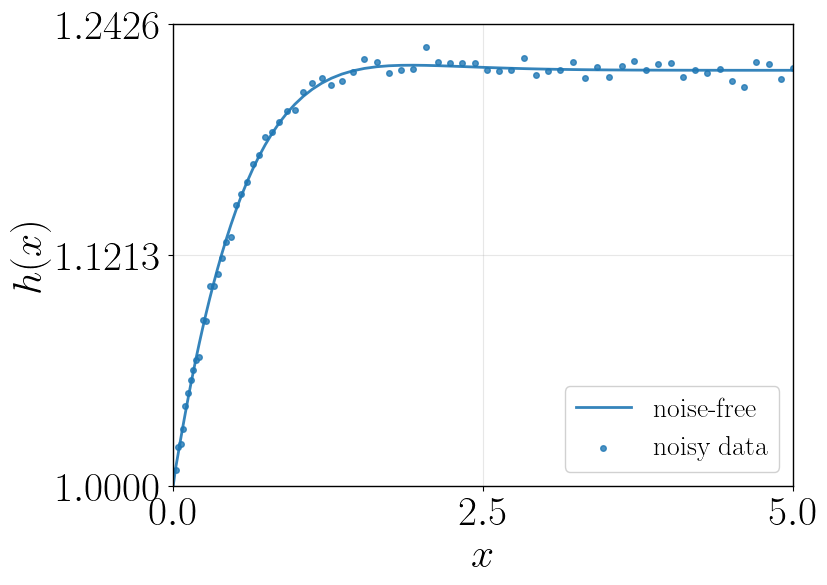

curve4_y GPR on (lambda, beta), 35 curves: 0.492**2 * RBF(length_scale=[0.63, 0.371])
MLE fit: lambda = 1.451, beta = 0.4892; sigma_MLE = RMS(delta) = 0.003109, max|delta(x)| = 0.005567
sigma_bias prior: exponential with mean sigma_MLE = 0.003109


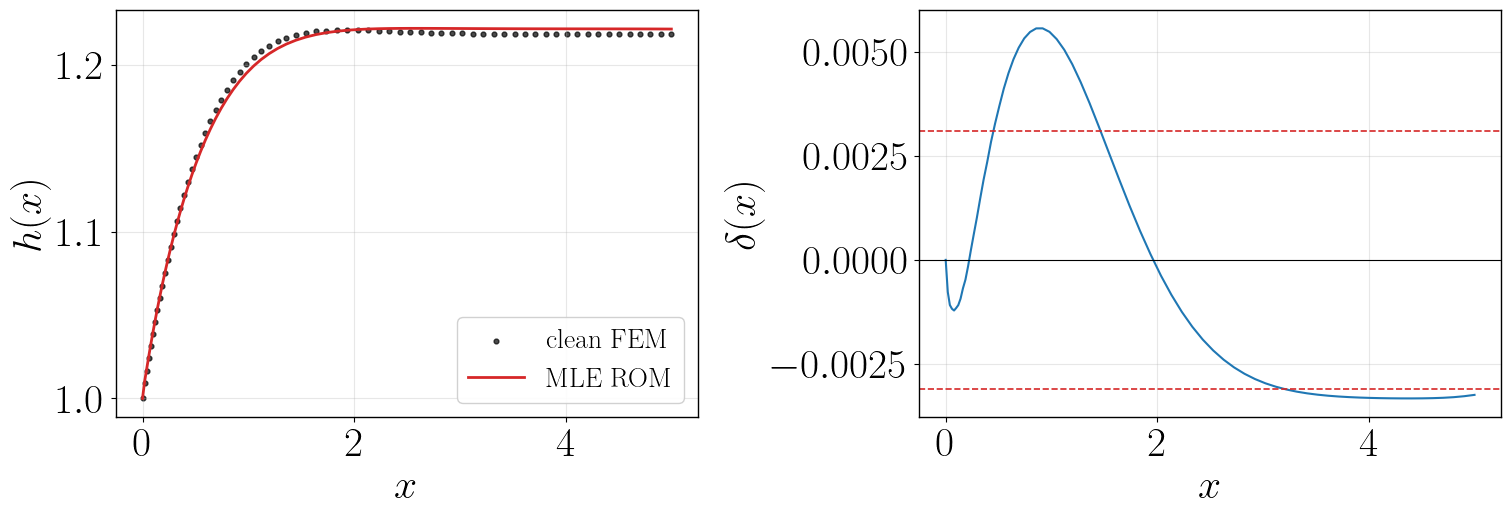

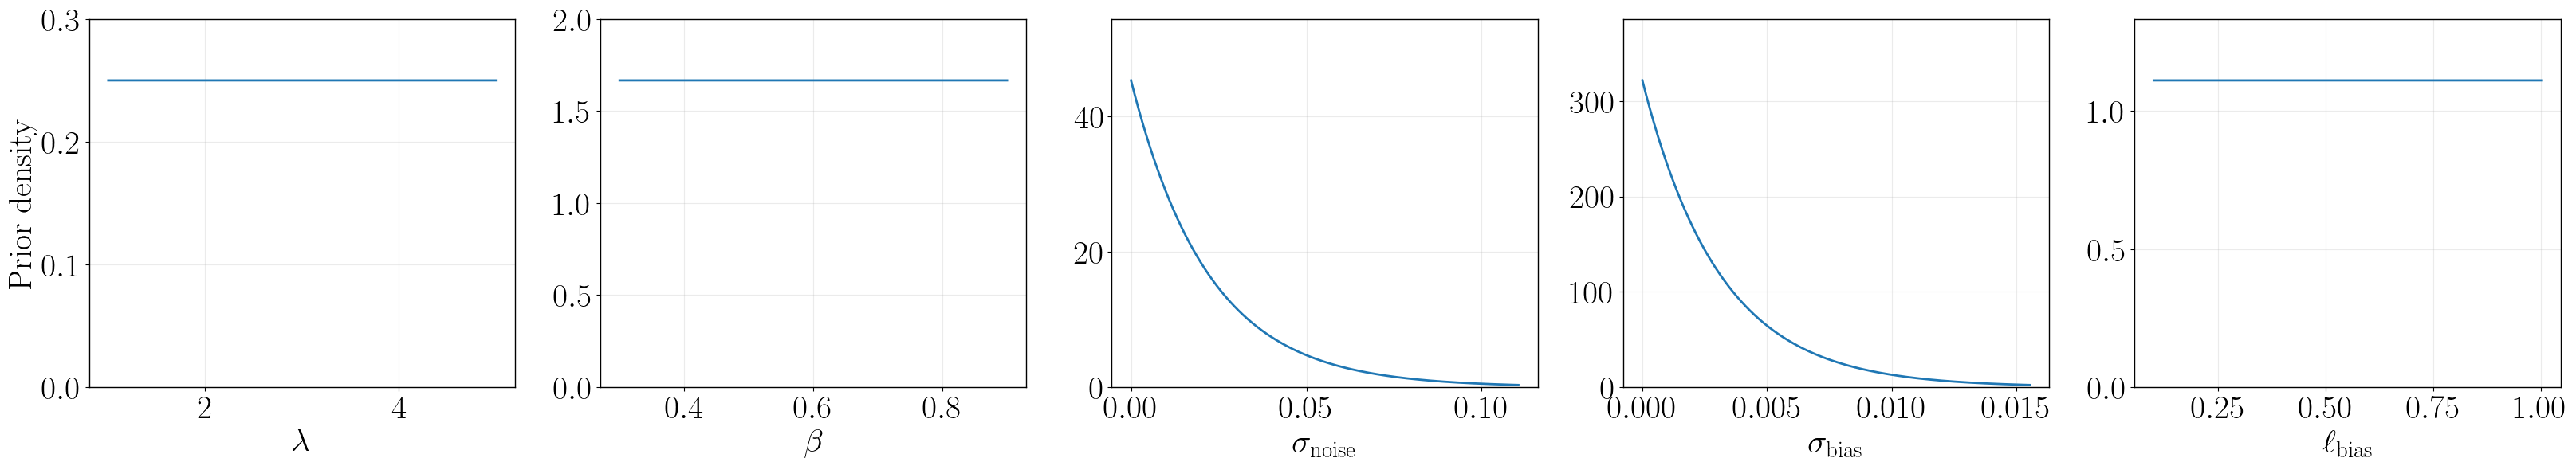

Initial walkers (first 20 of 20, physical space):
          lambda          beta   sigma_noise    sigma_bias        l_bias
          4.0958       0.56333      0.053117     0.0012448       0.47066
          4.4344       0.71842      0.065917      0.003573       0.46302
          1.3767       0.88537    0.00099237    0.00081568       0.93101
          4.0446       0.77164       0.02389    0.00055096       0.32129
          1.5125       0.57023     0.0026204     0.0044478       0.75683
          2.4832       0.85606    0.00013184    0.00010966       0.77912
          3.5755       0.79366      0.043085      0.001087       0.18801
          2.7737       0.43634      0.059423     0.0047808       0.52141
          3.2183       0.33829      0.025386     0.0013301       0.28051
          4.3105         0.679     0.0038064    0.00024128       0.26684
          4.0324       0.51272       0.03169     0.0003266       0.51745
          4.8828       0.83587     0.0045135     0.0023862       0.36049
 

100%|██████████| 2000/2000 [00:08<00:00, 235.09it/s]


Walkers restarted after warm-up (first 20 of 20, physical space):
          lambda          beta   sigma_noise    sigma_bias        l_bias
          1.2528       0.32929     0.0037023     0.0031717       0.55837
           1.361       0.35705     0.0037615     0.0038474        0.6765
          1.2748       0.33958     0.0036028     0.0037005       0.63021
          1.2999       0.34657     0.0038079     0.0034254       0.67322
          1.4236       0.30647      0.003672      0.002701       0.68978
          1.3734       0.31896     0.0036212     0.0026947       0.69288
          1.3543       0.34703     0.0036482     0.0033188       0.64512
          1.3282       0.36105     0.0037859     0.0035826       0.64072
          1.3317        0.3508     0.0035257     0.0029928        0.5926
          1.2857       0.31208     0.0039828     0.0026702        0.7213
          1.2339       0.30952     0.0037765     0.0035279        0.6983
          1.3567       0.30893     0.0036797     0.0036884

100%|██████████| 20000/20000 [01:21<00:00, 246.75it/s]


Parameter              Mean         Std      Rhat     90% CI Low    90% CI High
lambda           1.4320e+00  1.1115e-01     1.004     1.2990e+00     1.6460e+00
beta             4.5607e-01  9.2554e-02     1.003     3.2016e-01     6.1928e-01
sigma_noise      3.6056e-03  3.0892e-04     1.003     3.1351e-03     4.1495e-03
sigma_bias       3.7939e-03  1.2256e-03     1.001     2.2365e-03     6.0738e-03
l_bias           6.5575e-01  1.8004e-01     1.001     3.6722e-01     9.5292e-01
saved results to C:\Users\paraj\Documents\bayesian-die-swell-main\results\bias_true_infer-0.2_giesekus_lam_5_beta_0p5_alpha_0p2.txt
tau_w = R|dp/dx|/2 = 5.57318, gammadot_w = 4 U_avg / R = 0.8
E[N1] (oldroyd) = 6.85657 +/- 0.72036  (90% CI [5.5774, 7.89114], n=200000)
E[S_R] = 1.23028 +/- 0.129255  (90% CI [1.00076, 1.41591])  tau_w = 5.57318
true N1 (FEM, curve5_0002.txt) = 5.67015, true S_R = N1_true / tau_w = 1.0174, true gammadot_w = 0.846807
saved results to C:\Users\paraj\Documents\bayesian-die-swell-main\res

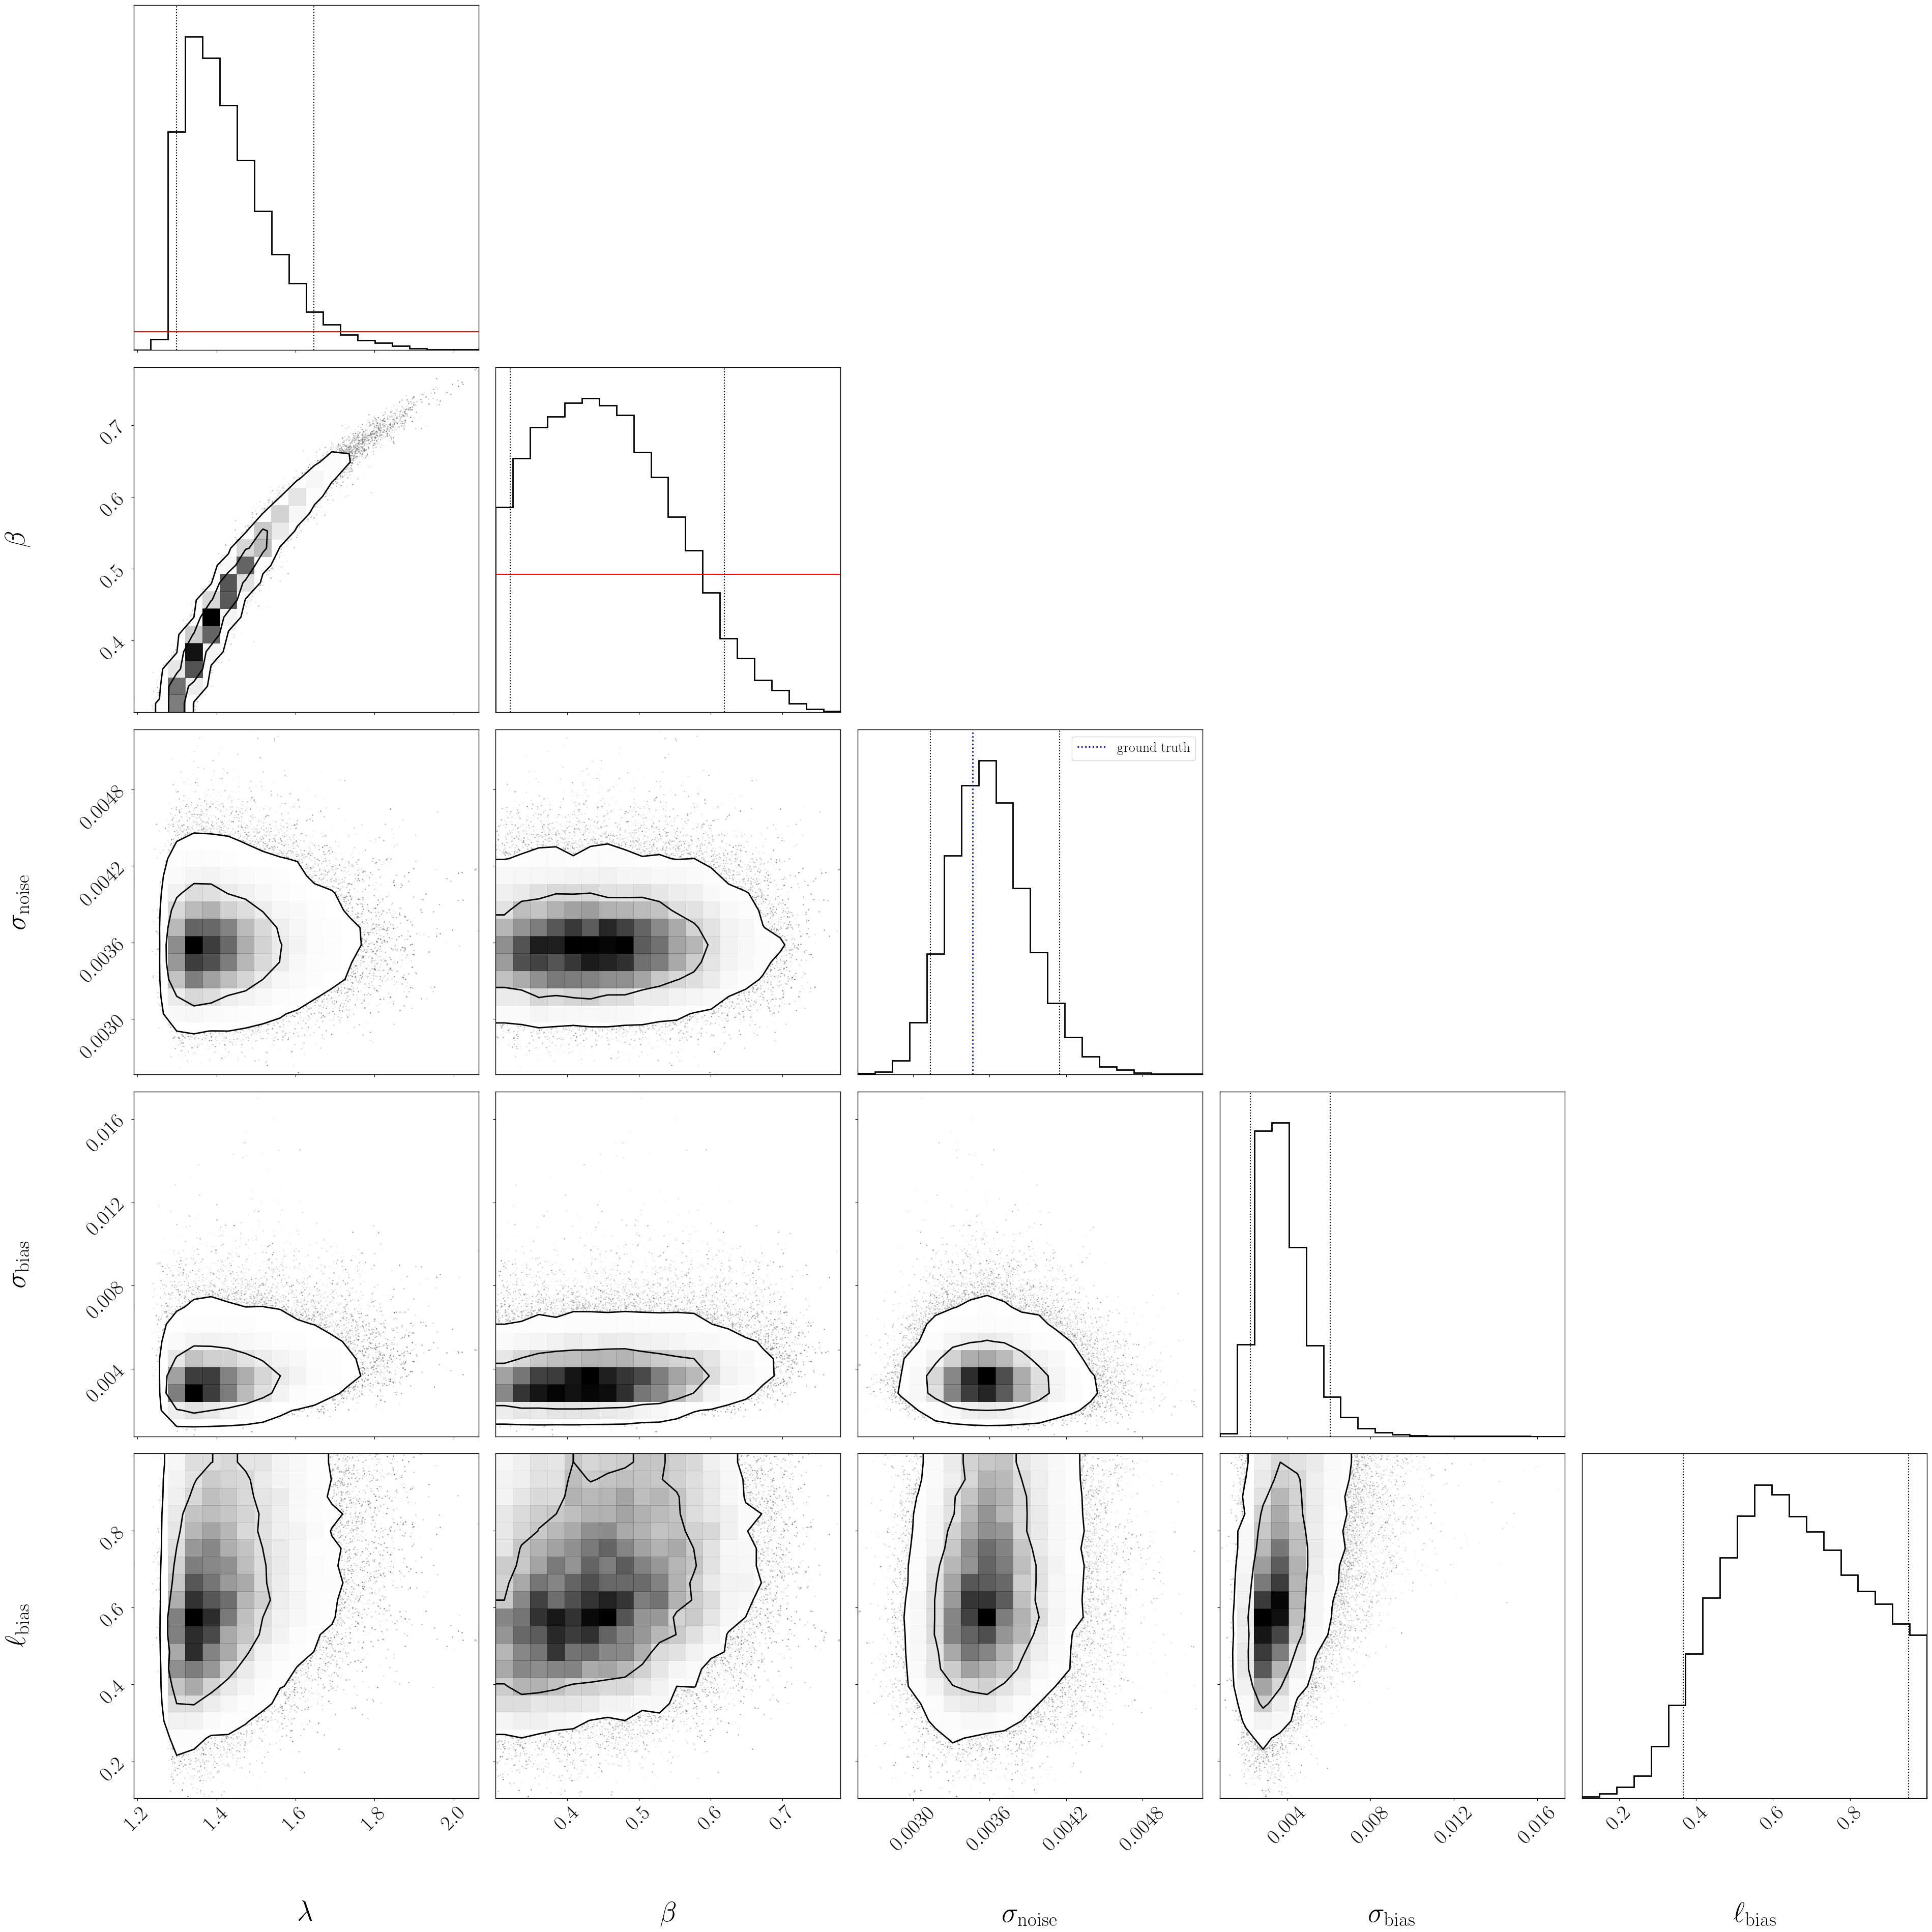

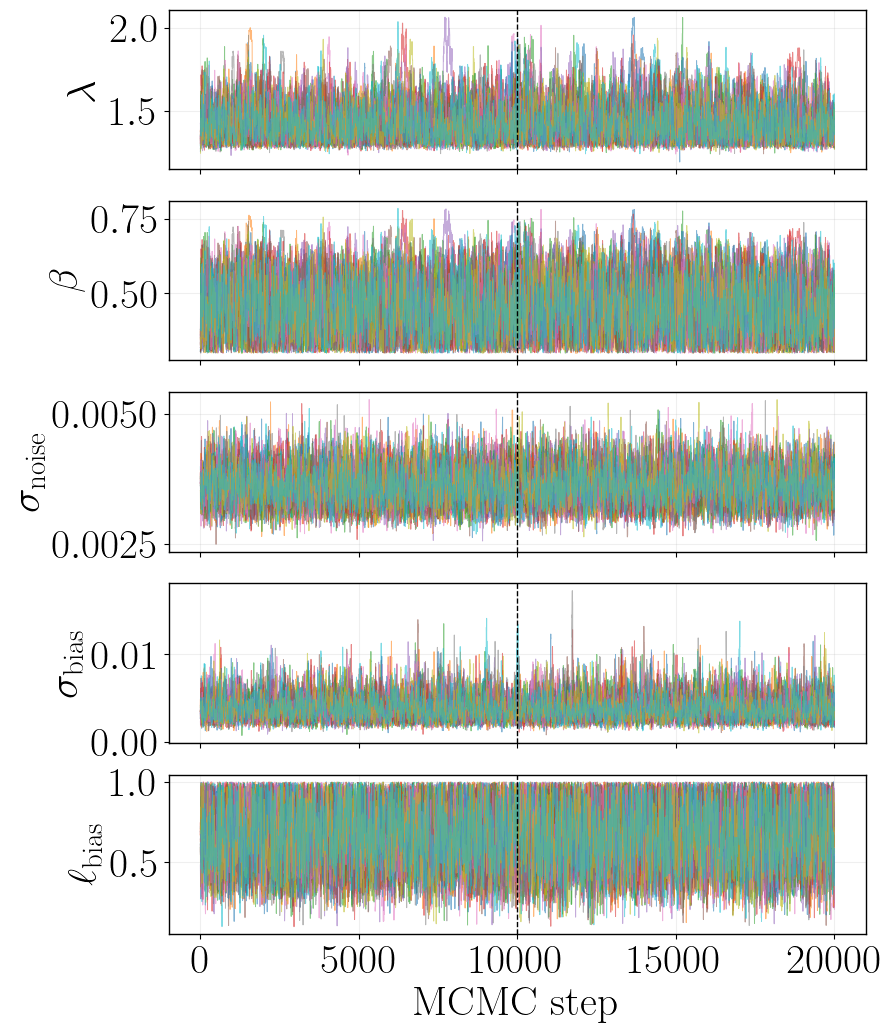


Posterior predictive (90% band)
  coverage=98.6%  rms_z=0.82  max|z|=2.02  mean_z=0.02


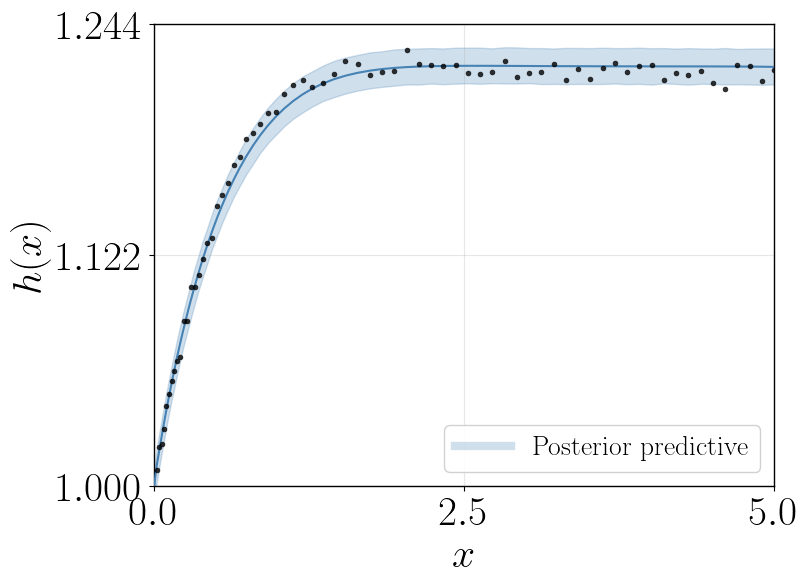

In [ ]:
import sys
import os
from pathlib import Path

CURRENT_DIR = os.getcwd()
FAXEN_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, '..'))
sys.path.append(FAXEN_ROOT)
from packages import ROMCurve4BayesianInference

model = ROMCurve4BayesianInference(
    swell_root=Path(FAXEN_ROOT),
    model="oldroyd",
    parametrize = False,   
    train_data_rels=["datas/oldroyd-rom2/train-0.2"],    
    filenames_train=("curve4_y_all.txt",  "parameters.txt"),  
    lambda_bounds = (1.0, 5.0),
    beta_bounds = (0.3, 0.9),
    sigma_noise_percent=2.0,
    thin=2,
    sigma_bias=True,
    constrained_model_error=True, 
    l_bias = "infer", U_avg = 0.2)

model.load_data(filename="datas/oldroyd-rom2/infer-0.2/giesekus_lam_5_beta_0p5_alpha_0p2/curve4_y.txt")
model.plot_data()
model.build_rom()
model.plot_prior()
model.run_mcmc(nwalkers=20, nsteps=20000, burn_fraction=0.5)
model.compute_N1()
model.plot_corner_all()
model.plot_trace_all()
model.plot_posterior_predictive()